In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import matplotlib.dates as mdates

In [12]:
tags = pd.read_csv('../data/zephyr_tags_with_date.csv',names=["tag", "created"], header=None)


In [16]:
tags=tags[ ~(tags.tag.str.contains('rc')) & ~(tags.tag.str.contains('99'))& ~(tags.tag.str.contains('mergebase')) ] 
tags['created']= pd.to_datetime(tags['created'])

In [17]:
def filter_by_major(tags, major="v1"):
    return tags[tags.tag.str.contains(major)]

def filter_by_patch(tags, patch=".0"):
    return tags[tags.tag.str.contains(patch)]
                


In [18]:
filter_by_major(tags,'v4')

,tag,created
0,v4.1.0,2025-03-07
5,v4.0.0,2024-11-15


In [19]:
filter_by_patch(tags)

,tag,created
0,v4.1.0,2025-03-07
5,v4.0.0,2024-11-15
11,v3.7.0,2024-07-26
17,v3.6.0,2024-02-23
22,v3.5.0,2023-10-20
26,v3.4.0,2023-06-16
31,v3.3.0,2023-02-19
36,v3.2.0,2022-09-30
41,v3.1.0,2022-06-05
48,v3.0.0,2022-02-21


In [20]:
tags['created']


0     2025-03-07
4     2024-11-21
5     2024-11-15
11    2024-07-26
16    2024-03-01
17    2024-02-23
22    2023-10-20
26    2023-06-16
29    2023-06-01
31    2023-02-19
35    2022-12-22
36    2022-09-30
40    2022-08-22
41    2022-06-05
46    2022-04-22
48    2022-02-21
52    2021-12-15
53    2021-11-15
54    2021-10-16
65    2021-06-04
69    2021-02-14
74    2020-09-27
78    2020-06-05
80    2020-05-29
82    2020-04-19
83    2020-03-10
87    2019-12-08
91    2019-10-06
93    2019-09-07
99    2019-04-16
103   2018-09-10
107   2018-06-11
111   2018-03-10
115   2017-12-08
119   2017-11-19
120   2017-10-11
121   2017-09-07
126   2017-06-15
132   2017-05-15
133   2017-05-15
136   2017-03-11
143   2016-12-03
148   2016-08-26
154   2016-06-03
158   2016-05-02
161   2016-04-02
164   2016-03-05
166   2016-02-08
Name: created, dtype: datetime64[ns]

In [21]:
filter_by_major(tags)['created']

53    2021-11-15
82    2020-04-19
91    2019-10-06
99    2019-04-16
103   2018-09-10
107   2018-06-11
111   2018-03-10
115   2017-12-08
119   2017-11-19
120   2017-10-11
121   2017-09-07
126   2017-06-15
132   2017-05-15
133   2017-05-15
136   2017-03-11
143   2016-12-03
148   2016-08-26
154   2016-06-03
158   2016-05-02
161   2016-04-02
164   2016-03-05
166   2016-02-08
Name: created, dtype: datetime64[ns]

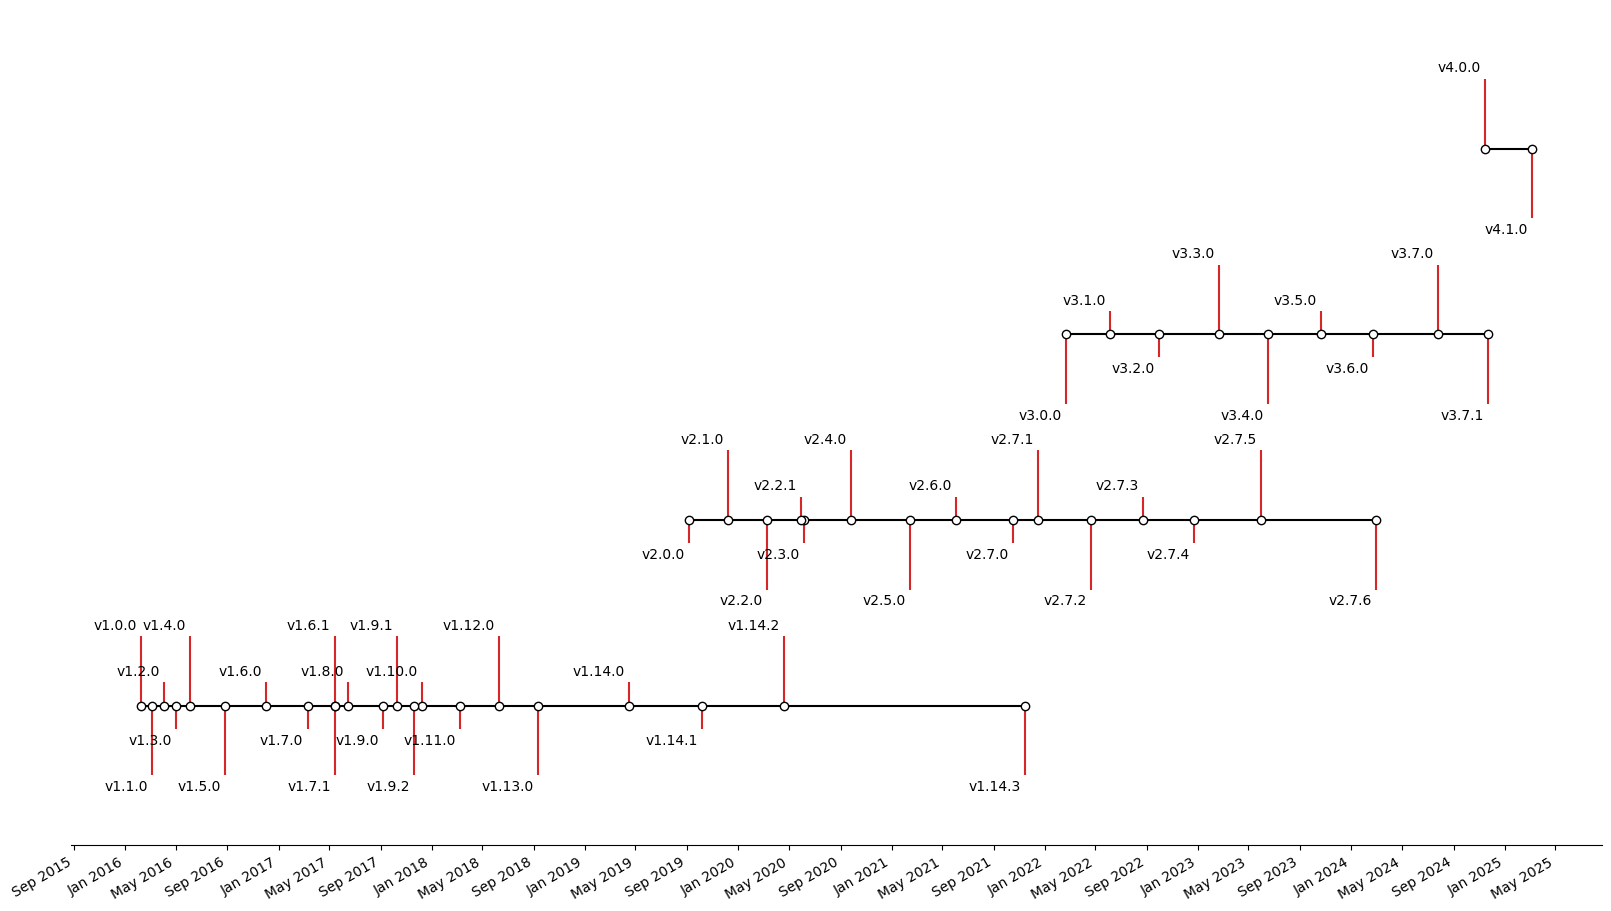

In [23]:
# Choose some nice levels
plt.rcParams["figure.figsize"] = [16, 9]
plt.rcParams["figure.autolayout"] = True


def add_major_to_plot(ax,tags,major, ofs=0,levels=[-3, 3, -1, 1]):
    filt_tags=filter_by_major(tags,major)
    names = filt_tags['tag']
    dates = filt_tags['created']
    levels = np.tile(levels,
                 int(np.ceil(len(dates)/len(levels))))[:len(dates)]
    
    ax.vlines(dates, ofs, ofs+levels, color="tab:red") 
    ax.plot(dates, ofs+np.zeros(len(dates)), "-o",
            color="k", markerfacecolor="w")  # Baseline and markers on it.

    # annotate lines
    for d, l, r in zip(dates, levels, names):
        ax.annotate(r, xy=(d, l+ofs),
                    xytext=(-3, np.sign(l)*3), textcoords="offset points",
                    horizontalalignment="right",
                    verticalalignment="bottom" if l > 0 else "top")


fig, ax = plt.subplots(figsize=(16,9), constrained_layout=True)

#ax.set(title="Zephyr release dates")
add_major_to_plot(ax,tags,'v1',ofs= 0)
add_major_to_plot(ax,tags,'v2',ofs= 8)
add_major_to_plot(ax,tags,'v3',ofs= 16)
add_major_to_plot(ax,tags,'v4',ofs= 24)


# format xaxis with 4 month intervals
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# remove y axis and spines
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()
fig.savefig('../figures/zephyr-release-dates.svg', format='svg')

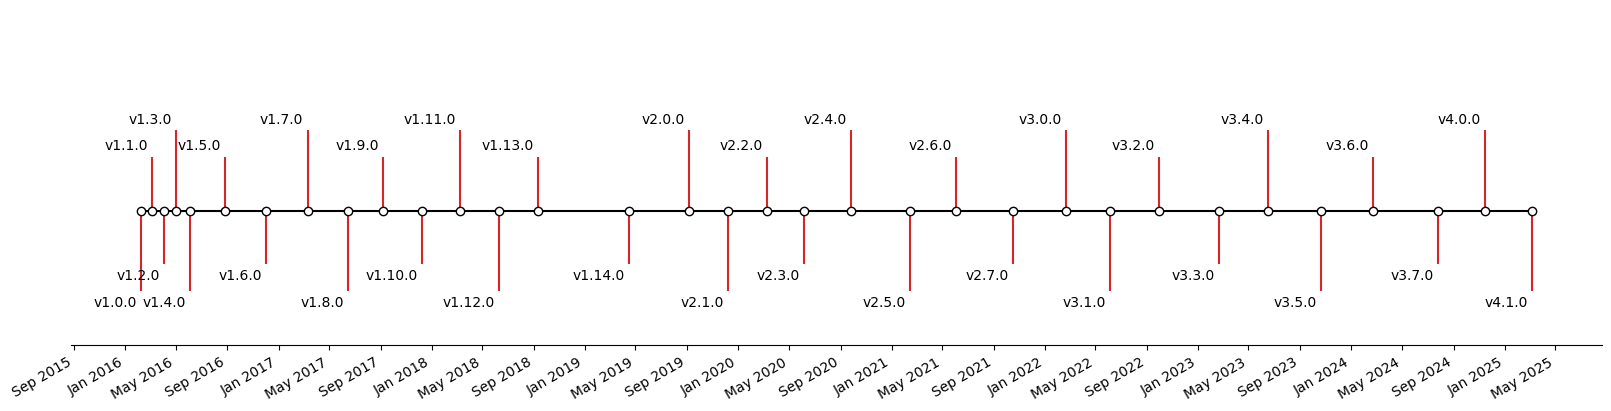

In [24]:
# Choose some nice levels
plt.rcParams["figure.figsize"] = [16, 6]
plt.rcParams["figure.autolayout"] = True

fig, ax = plt.subplots(figsize=(16,4), constrained_layout=True)

filt_tags=filter_by_patch(tags)
levels=[-1.2,1.2,-0.8,0.8]
ofs=0
names = filt_tags['tag']
dates = filt_tags['created']
levels = np.tile(levels,
             int(np.ceil(len(dates)/len(levels))))[:len(dates)]

ax.vlines(dates, ofs, ofs+levels, color="tab:red") 
ax.plot(dates, ofs+np.zeros(len(dates)), "-o",
        color="k", markerfacecolor="w")  # Baseline and markers on it.

# annotate lines
for d, l, r in zip(dates, levels, names):
    ax.annotate(r, xy=(d, l+ofs),
                xytext=(-3, np.sign(l)*3), textcoords="offset points",
                horizontalalignment="right",
                verticalalignment="bottom" if l > 0 else "top")



#ax.set(title="Zephyr release dates")

# format xaxis with 4 month intervals
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# remove y axis and spines
ax.yaxis.set_visible(False)
ax.set_ylim([-2,3])
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()
fig.savefig('../figures/zephyr-main-release-dates.svg', format='svg')